### note
<br/>

### note name

In [1]:
# pip install ipynbname

import ipynbname
nb_name = ipynbname.name()
nb_path = ipynbname.path()

nb_name

'2Samples Classical_GRU_P111 SEEDs_ini_2'

## Hyper parameters

In [2]:
SEED = 2
# SEEDs = range(10) # 0~9
L_RATE = 0.2 # 0.2
N_STEPS = 1000000
NUM_SEEDs = 50

In [3]:
from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
# from functools import partial
import time
import matplotlib.pyplot as plt
import pickle


from SQGRU_j7x import SQGRU, qgru
from Classical_RNN import simple_rnn, gru, count_parameters

### force to use cpu

In [4]:
jax.config.update('jax_platform_name', 'cpu')

In [5]:
qml.version()

'0.31.1'

## Oscillations

In [6]:
def damped_shm(fre, damp):
    amp = 0.7
    num_data = 151
    x = jnp.array(range(num_data))
    y = jnp.sin(x*fre)*jnp.exp(x*damp)*amp

    return y

In [7]:
osc1 = damped_shm(0.4, 0)
osc2 = damped_shm(0.6, -0.02)

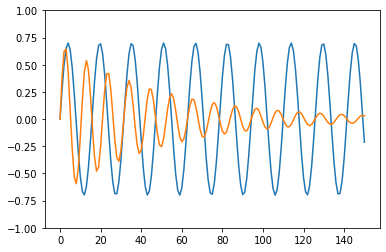

In [8]:
plt.plot(osc1)
plt.plot(osc2)
plt.ylim(-1,1)
plt.show()

In [9]:
oscillations = jnp.array([osc1,osc2])
true_data = jnp.expand_dims(oscillations, 2)
train_input = true_data[:,0:100,:]
train_target = true_data[:,1:101,:]

## Model
### Hyper parameters

In [10]:
# model parameters
OUT_DIM = 5

In [11]:
init_fun, qgru_rnn = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [12]:
key = jax.random.PRNGKey(SEED)
key1, key2 = jax.random.split(key, num=2)
_, params = init_fun(key1, jnp.shape(train_input))

In [13]:
count_parameters(params)

111

## Train

In [14]:
step_size = L_RATE
optimizer = optax.adam(step_size)
opt_state = optimizer.init(params)

In [15]:

@jax.jit
def loss_fn(params, xs, ys):
#     prediction = qgru_rnn(params, xs)[:,:,0:1]
    prediction = qgru_rnn(params, xs)
#     prediction = cls_predict(xs, 10, params)
    
    return jnp.mean((prediction - ys)**2) # the prediction shape


# def update(i_step, params, xs, ys, opt_state):
#     loss, grads = value_and_grad(loss_fn)(params, xs, ys)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss


In [16]:
minLoss = 1000
best_params = params
lossList = []
loc_params_list = []
reset_steps = []

In [17]:
def ck_lr(old_lr, new_lr):
    d_lr = old_lr - new_lr
    return d_lr >= 0 and d_lr/new_lr < 1e-2

### prediction

In [18]:
_, qgru_rnn2 = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [19]:
@jax.jit
def jit_rnn(params, inputs):
    return qgru_rnn2(params, inputs)

In [20]:
true1 = true_data.squeeze()[:,0:100]
true2 = true_data.squeeze()[:,100:]
xs = train_input

In [21]:
# for classical rnn to predict the trend
def cls_predict(inp, pred_length, params):
    ys = jit_rnn(params, inp)
    new_inp = inp
    for _ in range(pred_length-1):
        new_inp = jnp.concatenate([new_inp, ys[:,-1:]], axis=1)
        ys = jit_rnn(params, new_inp)
    return ys

### start

In [22]:
update_lr = True
lr_factor = 1
locLossList = [1000,1000,1000]
locLoss = 1000
loc_params = params



start = time.time()
for i in range(N_STEPS):
    
    if update_lr != 0:
        if update_lr < 0:
            params = loc_params
        else:
            locLossList = [1000,1000,1000]
            locLoss = 1000
            loc_params_list.append(loc_params)
            reset_steps.append(i)
            # reset parameters
            key1, key2 = jax.random.split(key2, num=2)
            _, params = init_fun(key1, jnp.shape(train_input))
            loc_params = params
            # stop when collect X local best parameters
            if len(loc_params_list) > NUM_SEEDs:
                break
        update_lr = 0
            
        # update learning rate
        optimizer = optax.adam(step_size)
        opt_state = optimizer.init(params)
        
        print('learning rate:', step_size)

        def update(i_step, params, xs, ys, opt_state):
            loss, grads = value_and_grad(loss_fn)(params, xs, ys)
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            return params, opt_state, loss
    
    pre_params = params
    params, opt_state, loss = update(i, params, train_input, train_target, opt_state)
    print('{}: {}   {} sec      '.format(i, loss, time.time()-start), end='\r')
    if loss < minLoss:
        best_params = pre_params
        minLoss = loss
    if loss < locLoss:
        loc_params = pre_params
        locLoss = loss
    if (i+1) % 100 == 0:
        # update learning rate?
        if loss > locLossList[0] and locLossList[1] > locLossList[0] and locLossList[2] > locLossList[0]:
            step_size /= 2
            update_lr = -1
        elif ck_lr(locLossList[2], loss) and ck_lr(locLossList[1], locLossList[2]) and ck_lr(locLossList[0], locLossList[1]):
            # reset
            step_size = L_RATE
            update_lr = 1
        locLossList[0] = locLossList[1]
        locLossList[1] = locLossList[2]
        locLossList[2] = loss
        
        
        lossList.append(loss)
        print('{}: {}   {} sec      '.format(i, loss, time.time()-start))

learning rate: 0.2
99: 0.0012156046555739204   1.5373115539550781 sec      
199: 0.001646362927015667   2.2376935482025146 sec       
299: 0.00035872023549045063   2.8970608711242676 sec      
399: 0.0002579905854245126   3.5163488388061523 sec       
499: 0.00019482622416407857   4.174952268600464 sec       
599: 0.00014580489029041057   4.830418586730957 sec       
699: 0.00011826229706774088   5.496922254562378 sec       
799: 9.968081225127257e-05   6.24172306060791 sec         
899: 0.000145848228195862   6.916428327560425 sec         
999: 0.00012529513268146427   7.657428026199341 sec       
1099: 0.0001115368328433   8.303800344467163 sec           
learning rate: 0.1
1199: 0.0002640810422470387   8.930049419403076 sec       
1299: 0.00022557666917045284   9.540969371795654 sec      
1399: 0.00015340343884176922   10.20774245262146 sec       
learning rate: 0.05
1499: 0.00014377249501225026   10.93330979347229 sec       
1599: 0.00011422740665658468   11.647024631500244 sec    

26599: 4.7680111142078265e-05   180.20231676101685 sec      
26699: 4.692477030877726e-05   180.86648082733154 sec       
26799: 4.5535278326734425e-05   181.50800895690918 sec      
26899: 4.537731451813128e-05   182.15920186042786 sec       
26999: 4.4635964704575584e-05   182.82165002822876 sec      
27099: 4.8842712067996836e-05   183.48295617103577 sec      
27199: 4.478294780483347e-05   184.15688252449036 sec       
27299: 4.29134331113384e-05   184.8186058998108 sec         
27399: 4.2665953707643755e-05   185.4855854511261 sec       
27499: 5.038293285009956e-05   186.13946962356567 sec       
27599: 4.785204844944589e-05   186.82594180107117 sec       
27699: 9.529521918535646e-05   187.50189876556396 sec       
learning rate: 0.0125
27799: 4.133012144328534e-05   188.18800449371338 sec       
27899: 4.0516846364024393e-05   188.84596300125122 sec      
27999: 3.988894318334288e-05   189.5095705986023 sec        
28099: 3.9247268796480115e-05   190.1697256565094 sec       
28

52799: 3.330381847322223e-05   354.0037319660187 sec        
52899: 3.328304036661857e-05   354.66120409965515 sec       
52999: 3.3265704533322674e-05   355.3022184371948 sec       
learning rate: 0.2
53099: 0.00030331149993259853   355.9524188041687 sec       
53199: 0.00022102137912703512   356.61579418182373 sec      
53299: 0.00016441592726977854   357.2554466724396 sec       
53399: 0.00013499463789391539   357.9113173484802 sec       
53499: 0.00011978430605255662   358.609570980072 sec        
53599: 0.0008464701591529453   359.2543079853058 sec        
53699: 0.00013018311162908743   359.92277812957764 sec      
53799: 0.00010763520163323896   360.56254506111145 sec      
53899: 9.415759451682288e-05   361.2356414794922 sec        
53999: 8.366729800406263e-05   361.8920650482178 sec       
54099: 7.598241909243329e-05   362.5383379459381 sec       
54199: 6.929576392366149e-05   363.1777777671814 sec       
54299: 0.00013035483904691819   363.9219722747803 sec       
54399: 7

78899: 4.361711022392944e-05   543.811564207077 sec        
78999: 4.2543978699337795e-05   544.5600395202637 sec      
79099: 4.1564879952836234e-05   545.3216562271118 sec      
79199: 6.913394008361865e-05   546.1486229896545 sec       
79299: 4.1317275441201014e-05   546.8854143619537 sec      
79399: 4.0410337681223107e-05   547.6548113822937 sec      
79499: 3.957327602297161e-05   548.464649438858 sec        
79599: 3.878573584561983e-05   549.2287707328796 sec       
79699: 3.804629695302847e-05   550.0089046955109 sec       
79799: 4.3194939105966934e-05   550.8226780891418 sec      
79899: 3.849870052518653e-05   551.7246999740601 sec       
79999: 3.765148443707137e-05   552.6027593612671 sec       
80099: 3.692646656144836e-05   553.3131649494171 sec       
80199: 3.629753336391696e-05   554.0450382232666 sec       
80299: 5.564391039393818e-05   554.7715940475464 sec       
80399: 3.718012767413417e-05   555.5519487857819 sec       
80499: 3.630201352614748e-05   556.28835

105399: 0.000188532633873318   780.7629098892212 sec        
105499: 0.00011942712103321749   781.6684226989746 sec      
learning rate: 0.1
105599: 0.0004746293781720691   782.6288225650787 sec       
learning rate: 0.05
105699: 0.00022785200818293522   783.5224313735962 sec      
105799: 0.0001465235819983618   784.4734354019165 sec       
learning rate: 0.025
105899: 0.00014565647222626336   785.3656780719757 sec      
105999: 0.00010037016822734224   786.2145621776581 sec      
106099: 8.873920373755014e-05   787.1368284225464 sec       
106199: 8.181219308736056e-05   788.0674636363983 sec      
106299: 7.700233796672366e-05   788.9687840938568 sec      
106399: 7.321322366180188e-05   789.853875875473 sec       
106499: 6.997893484425817e-05   790.8169662952423 sec      
106599: 6.709996164795543e-05   791.7711725234985 sec      
106699: 6.451476772479744e-05   792.7222337722778 sec      
106799: 6.214864559260089e-05   793.6329126358032 sec      
106899: 7.067820890930056e-05   

...

182999: 0.00010010222436226214   1518.7883949279785 sec      
183099: 8.087286152418865e-05   1519.684311389923 sec        
183199: 7.280561852967547e-05   1520.6177096366882 sec      
learning rate: 0.05
183299: 9.136138237319151e-05   1521.509978055954 sec        
183399: 6.741892204449167e-05   1522.4415040016174 sec      
183499: 6.228702760741082e-05   1523.4043700695038 sec      
183599: 5.866705910270032e-05   1524.387565612793 sec        
183699: 5.52873265810895e-05   1525.3234565258026 sec        
183799: 5.253830918473143e-05   1526.2756712436676 sec       
183899: 5.043876044210565e-05   1527.2050936222076 sec       
183999: 4.8702728535070476e-05   1528.2104392051697 sec      
184099: 4.714549905874761e-05   1529.097704410553 sec        
184199: 4.5676085967786405e-05   1530.0974609851837 sec      
184299: 4.425197149639698e-05   1531.1755683422089 sec       
184399: 4.285815287136104e-05   1532.1705405712128 sec       
184499: 4.149974501260648e-05   1533.0810656547546 se

208799: 4.4215863496907376e-05   1759.62730550766 sec        
208899: 4.44483507192088e-05   1760.5621564388275 sec        
208999: 4.129908833964174e-05   1761.4715242385864 sec       
209099: 3.987712145608577e-05   1762.4349060058594 sec       
209199: 0.0006703901566631217   1763.363166809082 sec        
209299: 3.8598858174817543e-05   1764.2119691371918 sec      
209399: 4.029840537565371e-05   1765.091469526291 sec        
209499: 6.457073926985634e-05   1765.9746024608612 sec       
209599: 3.7347071985400524e-05   1766.903148174286 sec       
209699: 4.5386382005237856e-05   1767.8506863117218 sec      
209799: 0.00021187969337815076   1768.7296731472015 sec      
209899: 3.843071265661956e-05   1769.5968761444092 sec       
learning rate: 0.05
209999: 7.242623037258807e-05   1770.5344116687775 sec       
210099: 4.608518223687479e-05   1771.435881137848 sec        
210199: 4.0172533533772115e-05   1772.362888097763 sec       
learning rate: 0.025
210299: 3.709839686422568e-05

234499: 9.198980975057813e-05   2000.4229481220245 sec       
234599: 8.396516102129574e-05   2001.3468825817108 sec      
234699: 7.603572268569129e-05   2002.2520904541016 sec      
234799: 6.829734596158557e-05   2003.2751200199127 sec      
234899: 6.152569176059701e-05   2004.2128324508667 sec      
234999: 5.678875162085031e-05   2005.1578941345215 sec       
235099: 5.398277951468742e-05   2006.0772166252136 sec       
235199: 5.205039074400648e-05   2007.0638535022736 sec       
235299: 5.049466617470863e-05   2007.9576189517975 sec       
235399: 4.919135687193944e-05   2008.9018766880035 sec       
235499: 4.8080637457127415e-05   2009.8738751411438 sec      
235599: 4.712276611838711e-05   2010.7855417728424 sec       
235699: 4.7476173840279077e-05   2011.6924023628235 sec      
235799: 4.555338179014541e-05   2012.6638045310974 sec       
235899: 4.490196916325665e-05   2013.6416833400726 sec       
235999: 4.431385377097684e-05   2014.620478630066 sec        
236099: 4.37

260399: 7.324507028563629e-05   2251.007574081421 sec        
260499: 5.6151256731263674e-05   2252.106657743454 sec       
260599: 5.190965043447953e-05   2253.2677369117737 sec       
260699: 5.4737593316732524e-05   2254.332743167877 sec       
260799: 5.2122036136256856e-05   2255.457328081131 sec       
260899: 7.251707297264744e-05   2256.5381128787994 sec       
learning rate: 0.025
260999: 0.029491353957844774   2257.606374502182 sec        
261099: 0.02802914959376083   2258.797797203064 sec        
learning rate: 0.0125
261199: 0.00010120158699993654   2259.9424481391907 sec      
learning rate: 0.00625
261299: 4.733901822203534e-05   2261.0617094039917 sec       
261399: 4.6453272702029765e-05   2262.165972471237 sec       
261499: 4.565511846369348e-05   2263.333610534668 sec        
261599: 4.546806484488625e-05   2264.4595103263855 sec       
261699: 4.426364434401049e-05   2265.5639338493347 sec       
261799: 4.314308268366982e-05   2266.691445350647 sec        
261899:

286099: 6.524060086170633e-05   2542.2043554782867 sec      
286199: 0.01743918008681427   2542.995534181595 sec         
286299: 0.04816507171262049   2543.842615365982 sec        
286399: 0.009781241767714425   2544.6306681632996 sec      
learning rate: 0.1
286499: 0.0004534690946982479   2545.453268766403 sec       
286599: 0.00021061215779289753   2546.2190437316895 sec      
286699: 0.000153958228238717   2547.0376632213593 sec        
286799: 0.0001288773169446789   2547.860292196274 sec        
286899: 0.00011467570821499119   2548.6847631931305 sec      
286999: 0.00010297858403369143   2549.489273786545 sec       
287099: 9.082070856600835e-05   2550.275857925415 sec        
287199: 8.082646114437514e-05   2551.0861341953278 sec      
287299: 7.248442879661722e-05   2551.933566570282 sec       
287399: 6.64996870319647e-05   2552.7304251194 sec          
287499: 0.0001561466950199418   2553.580414056778 sec        
287599: 6.993632794951783e-05   2554.448540210724 sec        

In [23]:
minLoss

Array(3.31015676e-05, dtype=float64)

In [24]:
# Save
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'wb') as f:
    pickle.dump((lossList, minLoss, params, best_params, loc_params_list, reset_steps), f)

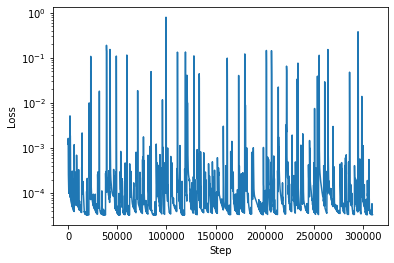

In [25]:
plt.plot([x*100 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

## Result

### best parameters

In [26]:
ys = cls_predict(xs, 50, best_params)

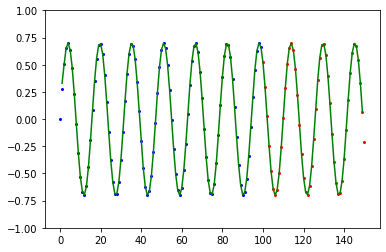

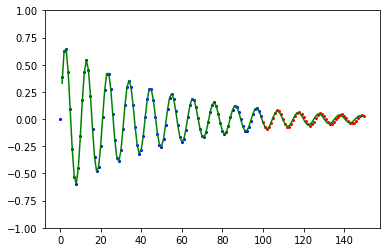

In [27]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

### final parameters

In [28]:
ys = cls_predict(xs, 50, params)

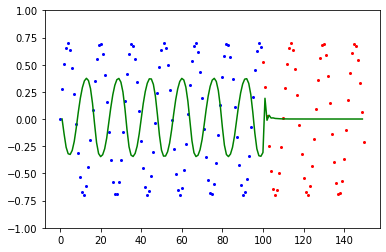

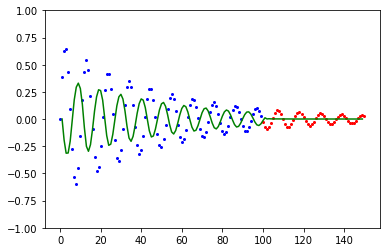

In [29]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

## Load & find the best parameters

In [22]:
# load
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

In [23]:
test_result = []
min_loss = 1000
k = 0
for i in reset_steps[1:]:
    k += 1
    j = int(i/100 -1)
    i_loss = lossList[j]
    i_params = loc_params_list[k]
    
    ys = cls_predict(xs, 50, i_params)
    
    t_loss = jnp.mean((true2[:,:-1]-ys[:,-50:,0])**2)
    test_result.append([i,i_loss,t_loss,i_params,ys])
    if t_loss < min_loss:
        min_loss = t_loss
        min_idx = k-1
        min_ys = ys
        
test_result[min_idx]

[89600,
 Array(3.31015676e-05, dtype=float64),
 Array(8.60122711e-05, dtype=float64),
 [((Array([[-0.73015842,  1.56116958,  0.3931214 ,  3.1859088 ,  0.11892289]],      dtype=float64),
    Array([[ 1.62315201,  0.16266874,  4.21313905, 13.18533109,  1.35348103],
           [-1.1085688 , -3.28328463,  1.58066325, -3.47212393, -0.64793422],
           [ 1.82454536, -0.4148691 , -1.38704383, -1.93331066, -0.53339683],
           [-2.52450142,  4.54511255,  1.06879781, -3.88682952,  1.28228127],
           [ 0.47617275, -0.54471932, -1.20871062, -6.26246406,  0.58521225]],      dtype=float64),
    Array([-0.67252301,  1.88692443, -2.60198425,  1.24941279, -0.41585356],      dtype=float64)),
   (Array([[-3.30363941, -1.04519667, -1.51268554, -3.30043171,  0.24117027]],      dtype=float64),
    Array([[ 1.43067581,  0.48608376,  1.20303834, -0.07376895, -1.81229683],
           [ 0.21809483,  0.43875104,  1.94738335, -1.74815341, -1.15559433],
           [-3.30915269, -0.38995834, -1.102319

In [24]:
# Save results
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

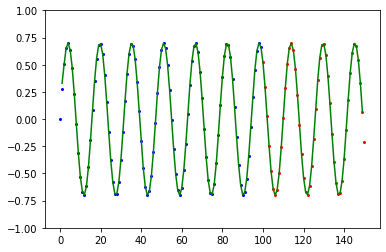

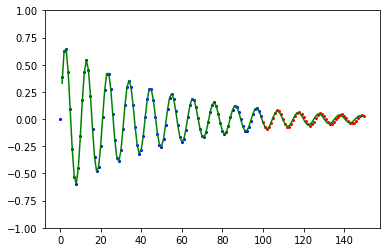

In [32]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(min_ys[idx])))+1, min_ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

best: [89600, Array(3.31015676e-05, dtype=float64), Array(8.60122711e-05, dtype=float64)]
6200 3.946308594777528e-05 0.23677129074942713


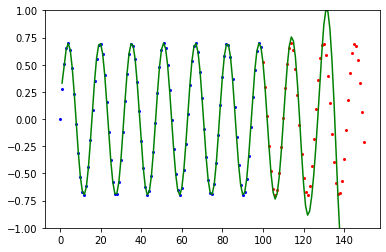

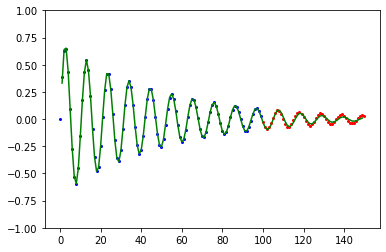

13800 3.7487654843070945e-05 0.02552944546633646


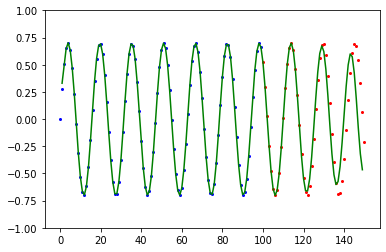

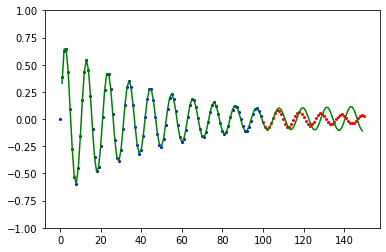

21200 3.328586302100602e-05 0.00035236930970962725


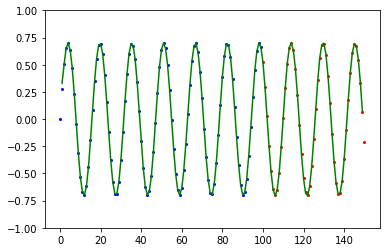

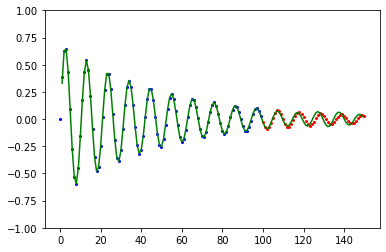

30000 3.452272334334067e-05 0.025295702862451166


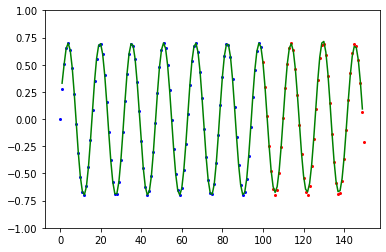

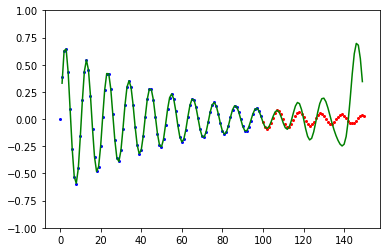

38100 3.322771478371121e-05 0.052586546168059016


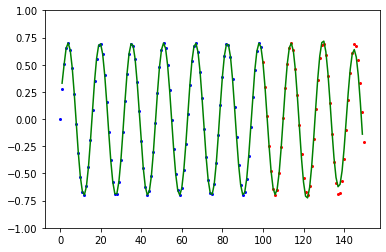

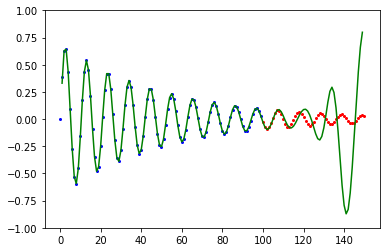

46300 8.498007775778745e-05 0.12524837118384238


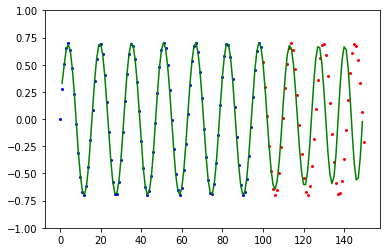

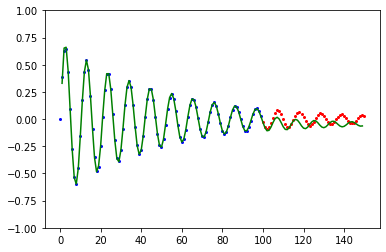

53000 3.3265704533322674e-05 0.008134517620706884


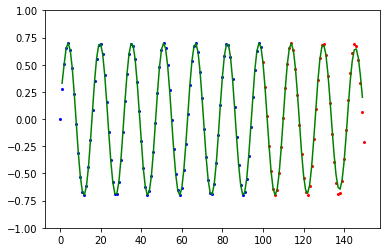

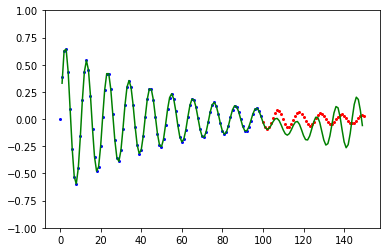

58000 3.361575492837792e-05 0.0302300815571787


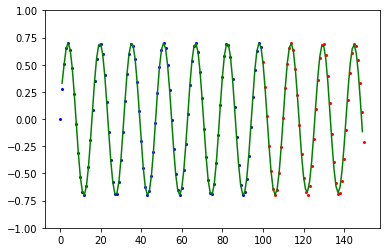

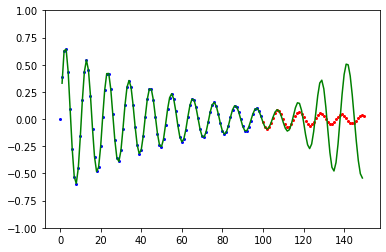

62600 3.326319292006993e-05 0.0001942946673728764


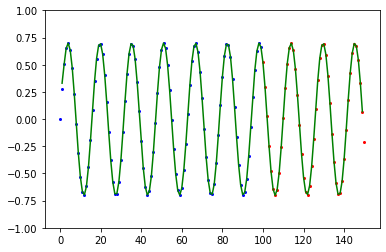

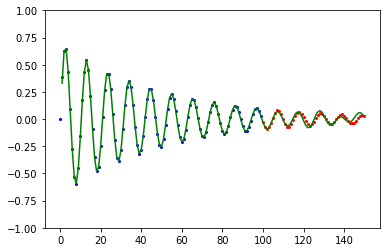

69100 3.708628036437153e-05 0.08901127879619548


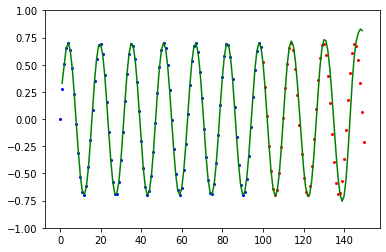

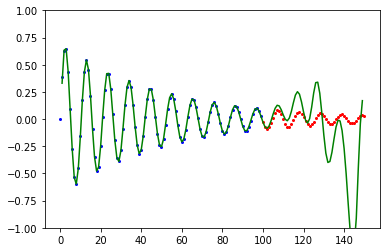

75600 3.563528160334333e-05 0.06605971363348355


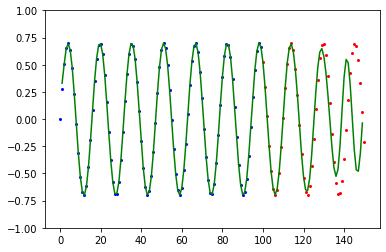

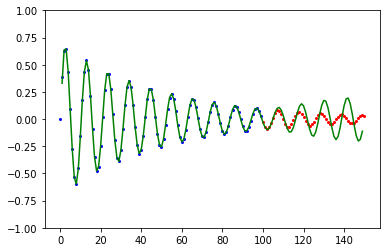

81200 3.440304868584537e-05 0.00018466158528324103


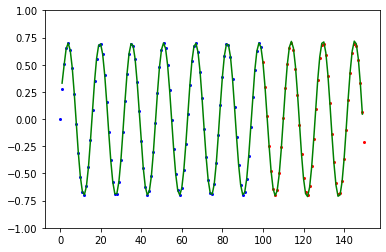

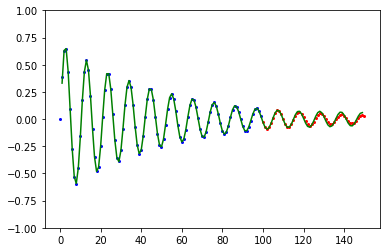

89600 3.310156762580134e-05 8.601227114254027e-05


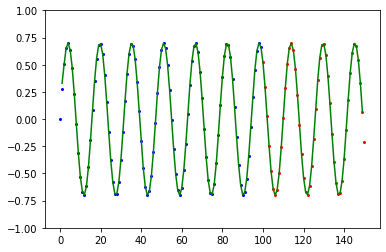

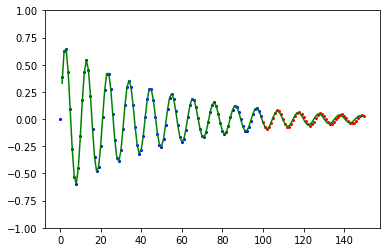

95300 3.483386156939536e-05 0.002292789768342349


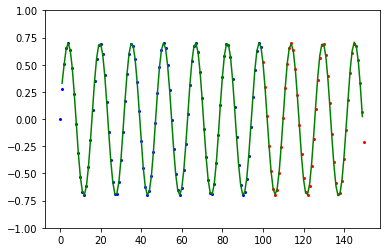

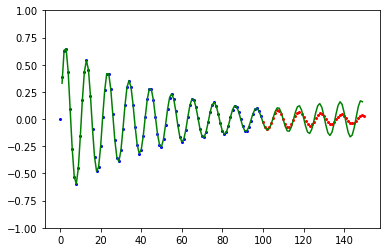

98200 3.4033554139248754e-05 0.004428709055557603


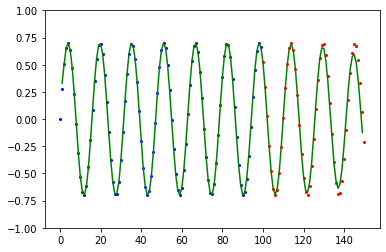

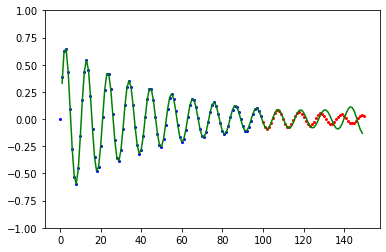

104400 3.494304382526863e-05 0.014838912228496584


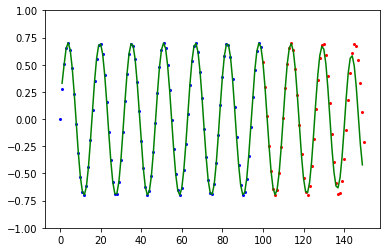

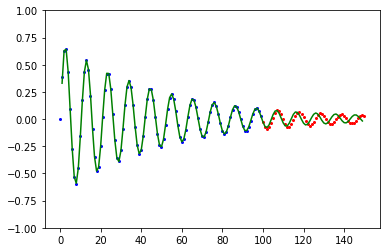

110500 3.9281428024569725e-05 0.00860002929701991


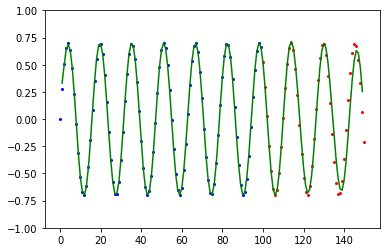

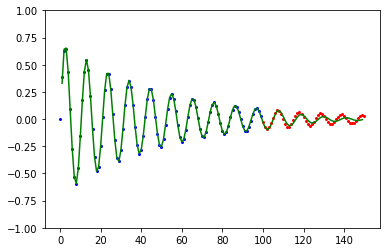

118500 3.323598103232852e-05 0.00025664310486111684


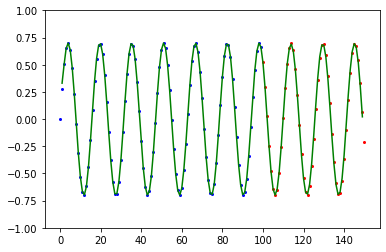

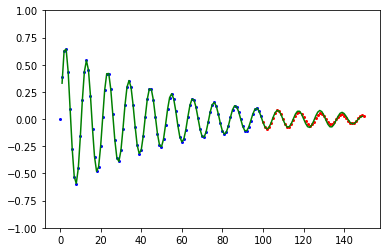

121700 0.009903211603022828 0.06315644268790929


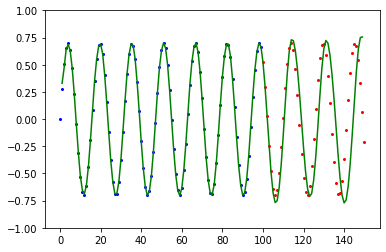

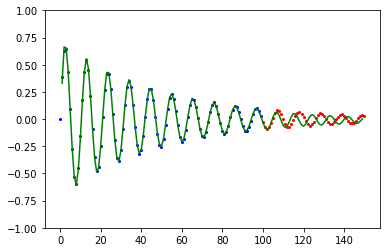

127300 3.615728069827293e-05 0.005822118253187668


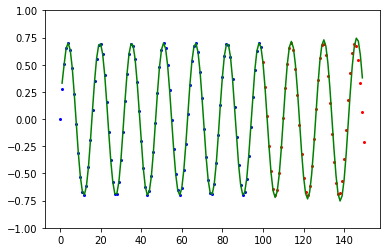

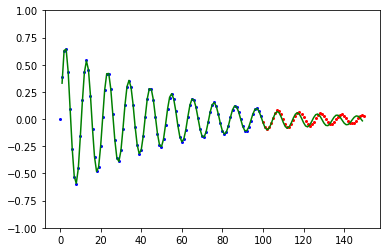

131200 3.3444243156547774e-05 0.00012364329038819726


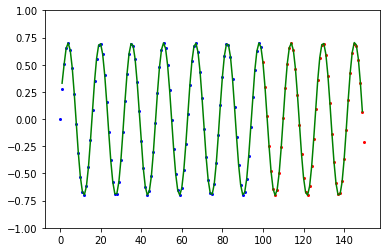

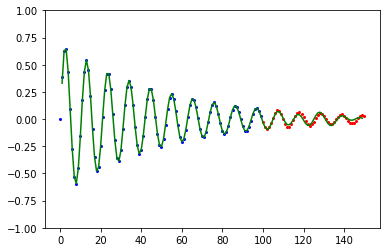

137900 3.692038827651907e-05 0.0018892988946002981


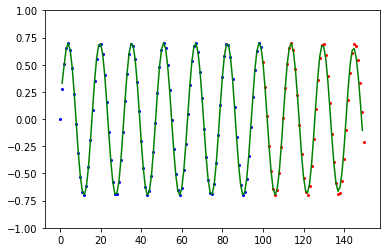

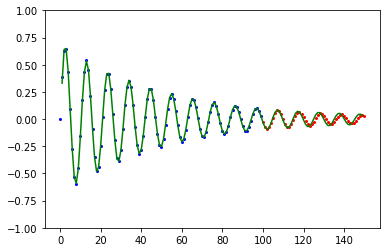

142800 3.747566998040949e-05 0.025151058292247685


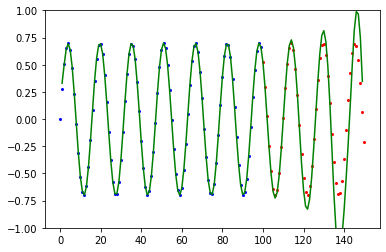

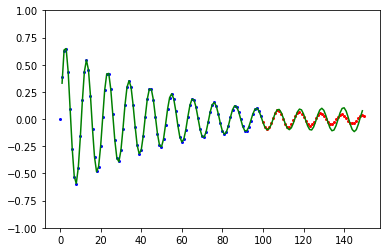

146700 3.5752289590590764e-05 0.002719526412513589


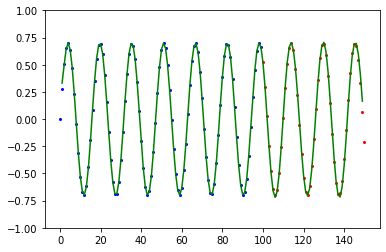

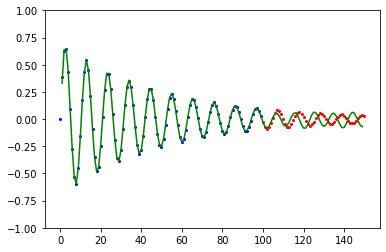

151800 3.58045200120309e-05 0.05029811882277935


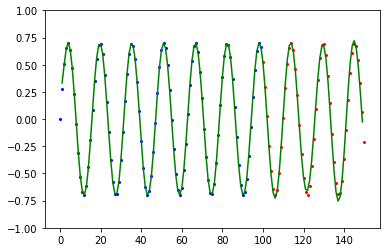

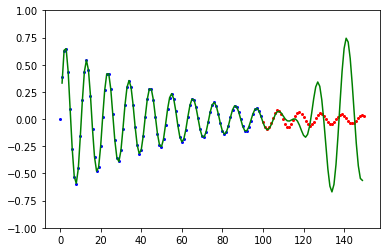

160300 4.5218858208472e-05 0.047223733314638174


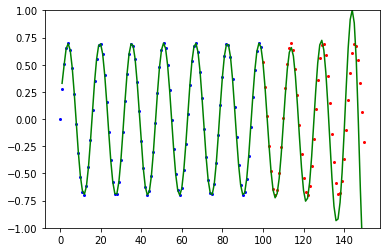

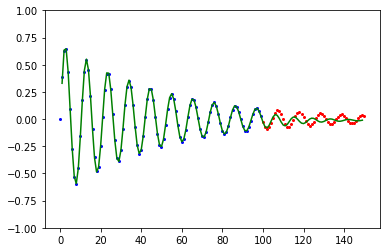

165300 3.362842806980794e-05 0.0008618778645044542


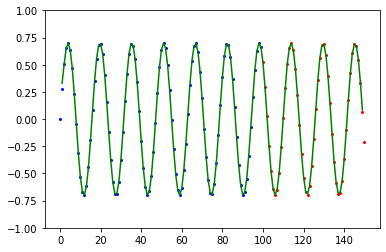

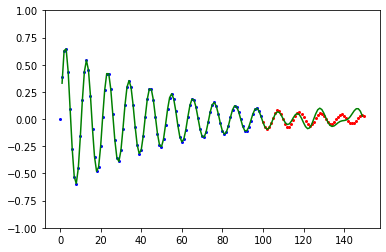

174100 3.378204822175383e-05 0.024791918922876792


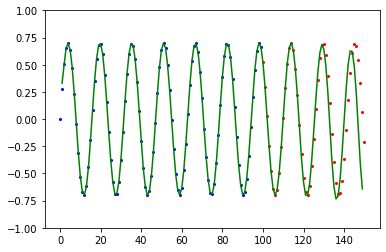

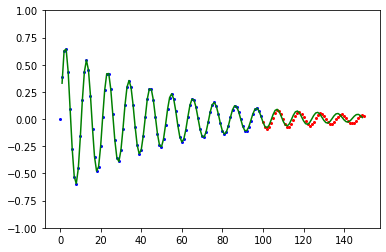

179400 3.619322582197914e-05 0.04950559223899787


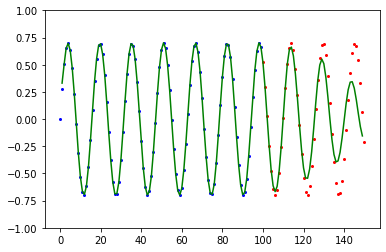

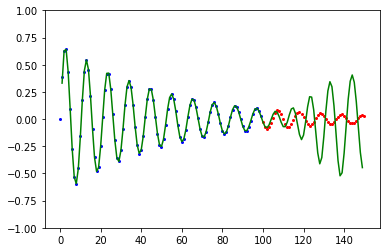

180500 0.008888906595609213 0.1893698432872896


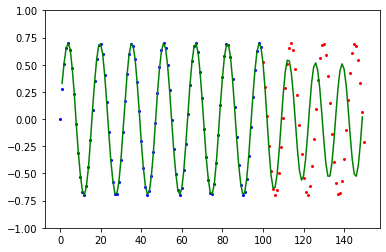

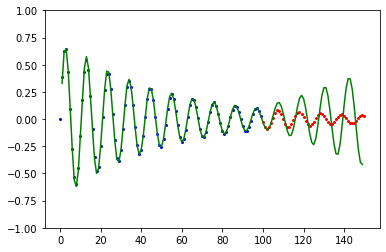

186700 3.471984656992348e-05 0.012149458906084256


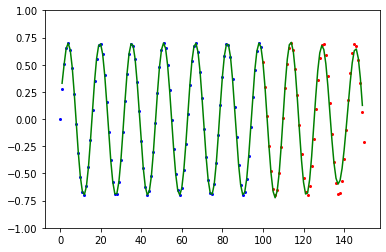

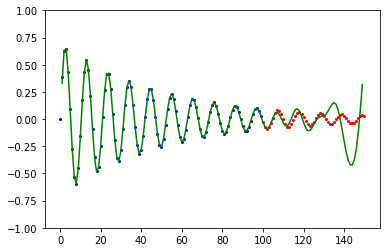

198500 3.352867792650448e-05 0.1697045696231514


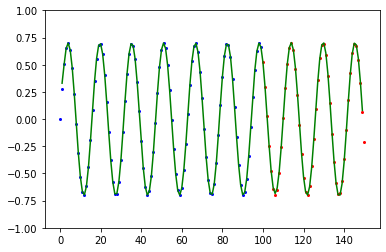

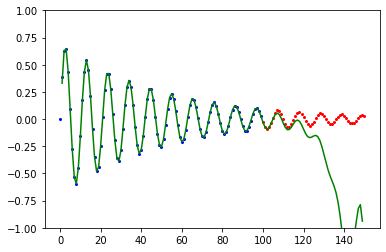

202900 3.391129240901966e-05 0.19417237580192295


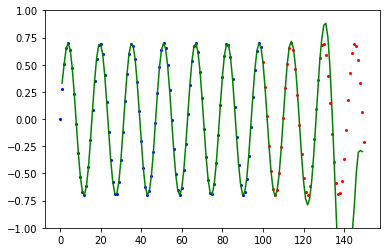

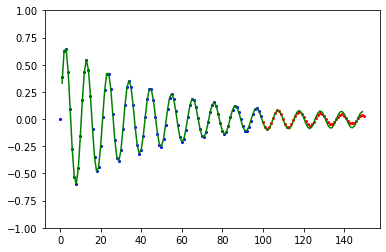

206300 3.854109524933292e-05 0.013638634192538895


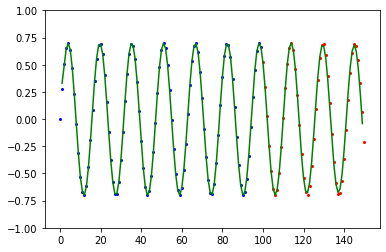

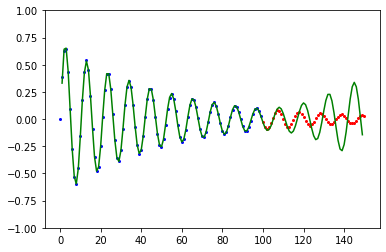

213000 3.3787889532904327e-05 0.004643269907264131


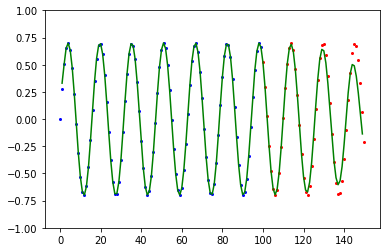

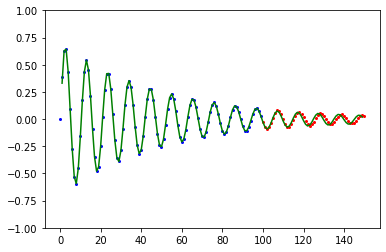

221300 3.488074583935026e-05 0.09066595678914809


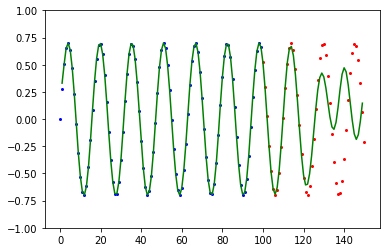

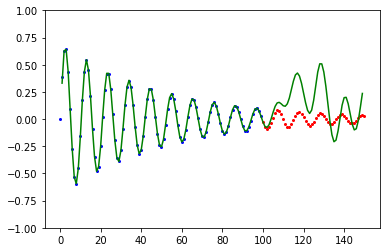

227400 3.925484773381225e-05 0.028018169897491035


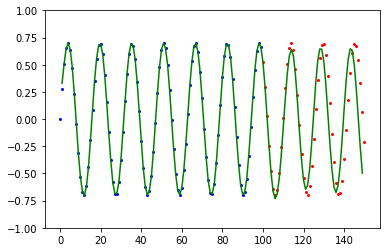

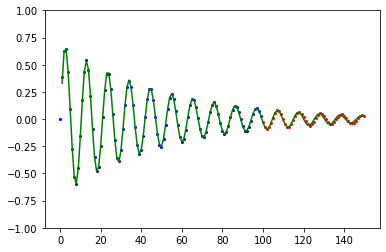

231100 3.6290272538779474e-05 0.009854036338390403


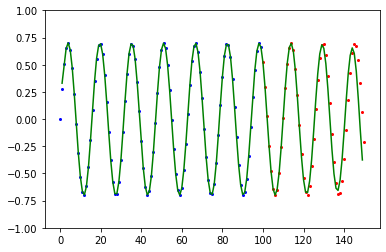

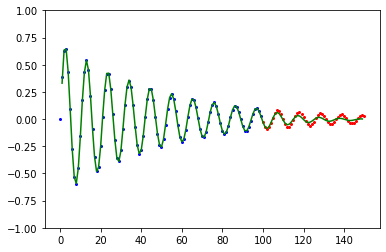

236700 4.12478191474103e-05 0.13446809576217633


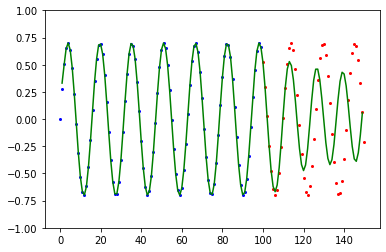

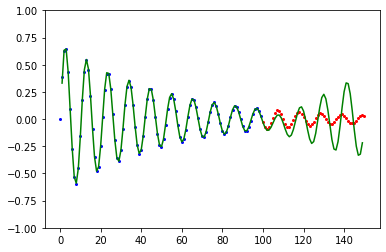

244400 3.594780927736279e-05 0.07500703243588501


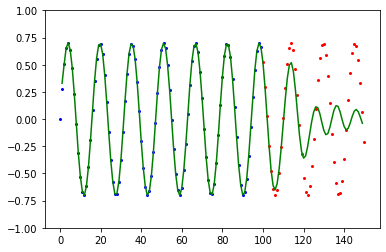

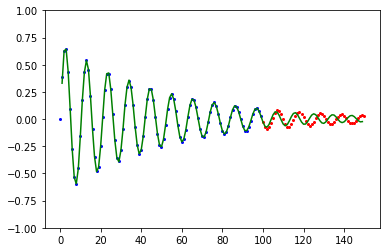

251700 3.413232112439316e-05 0.0004912727973404244


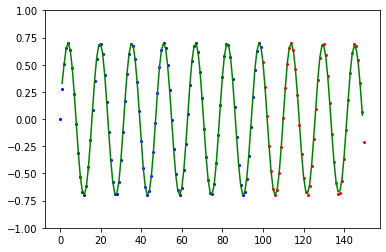

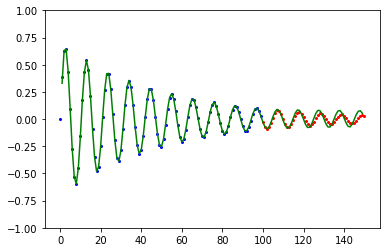

254700 3.369738475427817e-05 0.05255516988622115


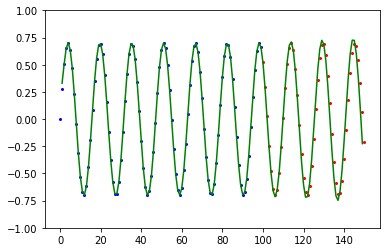

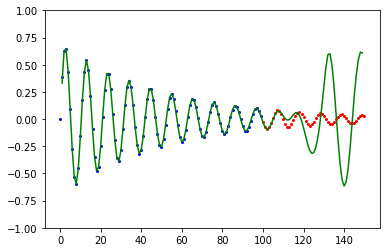

263200 3.5955627967073764e-05 0.04333751850918915


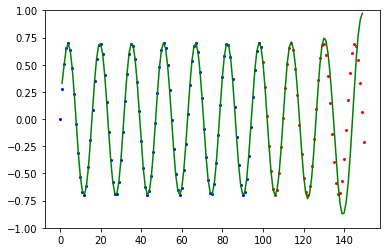

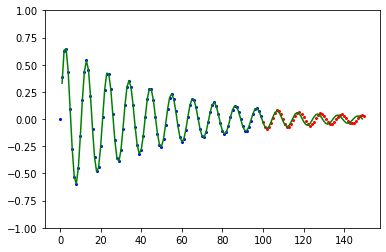

276600 3.5588786958065294e-05 0.2908058008847523


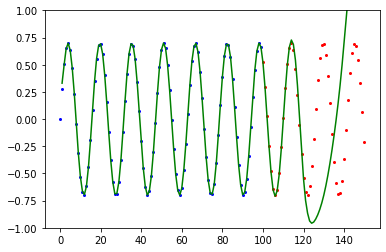

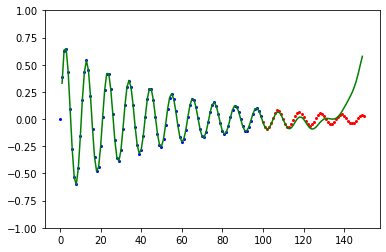

281400 3.532295213733025e-05 0.29822010610487754


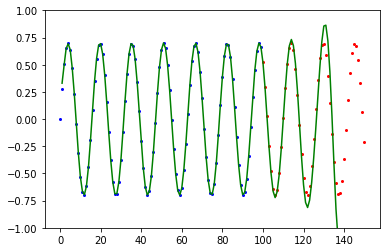

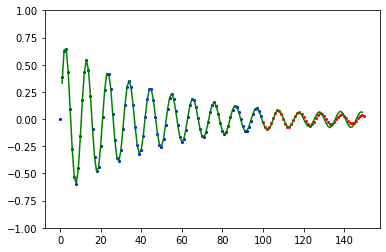

285200 3.387725409370031e-05 0.0013991205774751259


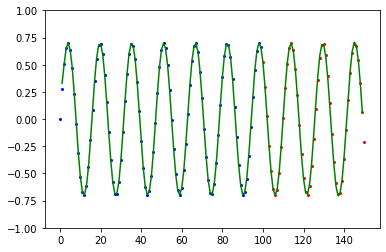

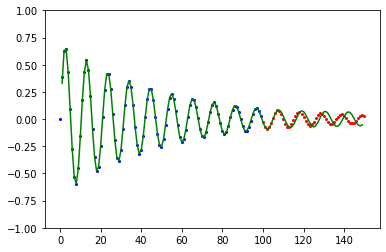

291200 3.385032623505422e-05 0.05315484628042132


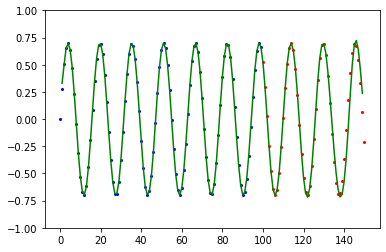

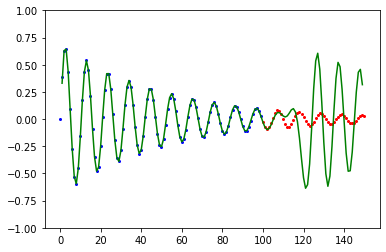

297900 3.4826687414948275e-05 0.03844180541410531


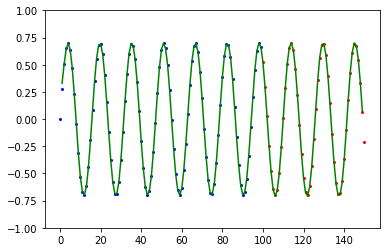

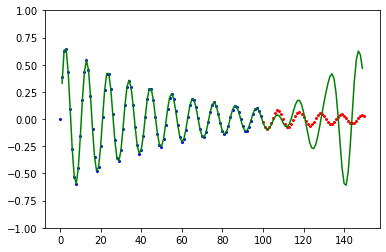

304300 3.336363644729786e-05 0.028343637873152337


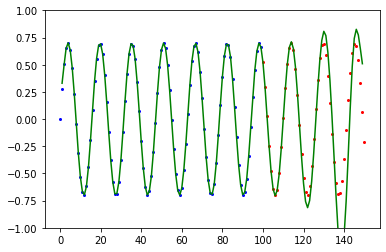

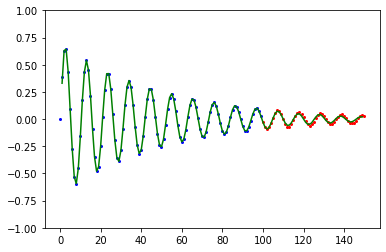

309600 3.353730311875181e-05 0.3079450412923233


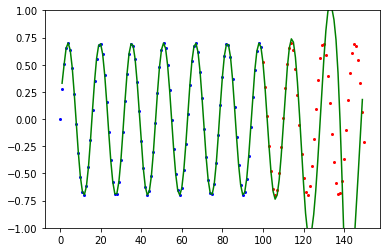

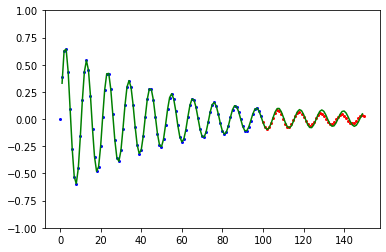

In [33]:
print('best:', test_result[min_idx][0:3])
for pak in test_result:
    i, i_loss, t_loss, _, ys = pak
    print(i, i_loss, t_loss)
    for idx in [0, 1]:
        plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
        plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
        plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
        plt.ylim(-1,1)
        plt.show()

In [34]:
sum([_[2] for _ in test_result])/len(test_result)

Array(0.05996061, dtype=float64)

In [35]:
len(test_result)

50